# T8 · A network from scratch: forward, backprop, gradient check, SGD to Adam

Every arm in this project that contains a network gets its gradients from
torch. This notebook does the same job by hand, in NumPy, so that each step
can be read and checked: the forward pass, the backward pass, a gradient check
against finite differences and against torch, the choice of initialisation,
and five optimizers from plain SGD to Adam.

The code lives in `physprior.optim.scratch`. It is short on purpose.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


In [2]:
from physprior.optim import scratch as S

net = S.init_mlp([1, 16, 16, 1], activation="tanh", seed=0)
x, y, t = S.demo_data(64)          # a damped oscillation, inputs scaled to [-1, 1]
out, cache = S.forward(net, x)
print("layer sizes", net.sizes, "  parameters", net.n_params())
print("output", out.shape, "  cached activations", [a.shape for a in cache["a"]])

layer sizes [1, 16, 16, 1]   parameters 321
output (64, 1)   cached activations [(64, 1), (64, 16), (64, 16), (64, 1)]


## 1. Forward and backward

Forward: `a_0 = x`, `z_l = a_{l-1} W_l + b_l`, `a_l = tanh(z_l)`, and the last
layer is linear. The loss is `L = mean((y_pred - y)^2)`.

Backward, with `delta_l = dL/dz_l`:

- output layer: `delta_L = dL/dy_pred = 2 (y_pred - y) / N`
- each layer: `dL/dW_l = a_{l-1}^T delta_l`, `dL/db_l = sum over rows of delta_l`
- one layer down: `delta_{l-1} = (delta_l W_l^T) * tanh'(z_{l-1})`, with
  `tanh' = 1 - tanh^2`

That is the whole of backpropagation: the chain rule applied once per layer,
reusing what the forward pass cached. The cost is about two forward passes,
whatever the number of parameters.

In [3]:
loss, g = S.loss_and_grad(net, x, y)
g_torch = S.torch_grad(net, x, y)
print(f"loss {loss:.4f}   |grad| {np.linalg.norm(g):.4f}")
print(f"relative difference, backprop vs torch autograd: "
      f"{np.linalg.norm(g - g_torch) / np.linalg.norm(g):.1e}")

loss 0.2009   |grad| 0.7078
relative difference, backprop vs torch autograd: 3.2e-16


## 2. The gradient check, and its own convergence

A central difference `(L(theta + h e_k) - L(theta - h e_k)) / 2h` has
truncation error O(h^2) and round-off error ~ eps / h. So the check is itself
a numerical method with a convergence study: the error against backprop
should fall with slope 2 on a log-log plot until round-off takes over.

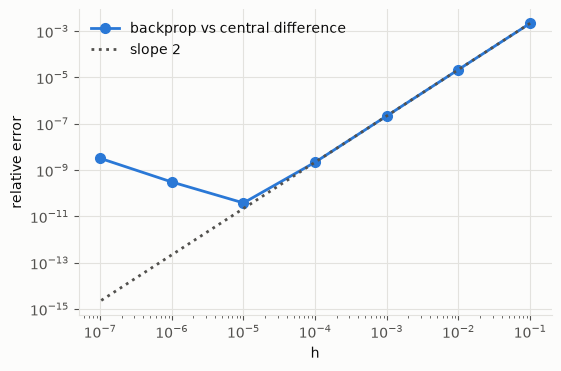

h = 1e-01   error = 2.19e-03
h = 1e-02   error = 2.20e-05
h = 1e-03   error = 2.20e-07
h = 1e-04   error = 2.20e-09
h = 1e-05   error = 3.83e-11
h = 1e-06   error = 3.07e-10
h = 1e-07   error = 3.24e-09


In [4]:
rows = S.fd_convergence(net, x, y, steps=(1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7))
hs = np.array([r["h"] for r in rows]); errs = np.array([r["rel_error"] for r in rows])
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.loglog(hs, errs, "o-", color=P.ARM_COLOR["physics"], label="backprop vs central difference")
ax.loglog(hs, errs[1] * (hs / hs[1])**2, ":", color=P.INK_2, label="slope 2")
ax.set_xlabel("h"); ax.set_ylabel("relative error"); ax.legend()
plt.show()
for r in rows: print(f"h = {r['h']:.0e}   error = {r['rel_error']:.2e}")

## 3. Initialisation

The variance of a layer's pre-activation is `fan_in * Var(W) * Var(input)`.
To keep it near one through depth, `Var(W)` must scale like `1/fan_in`.
Xavier uses `2 / (fan_in + fan_out)` and suits tanh; He uses `2 / fan_in`
because ReLU zeroes half its inputs. Below: eight layers of width 64.

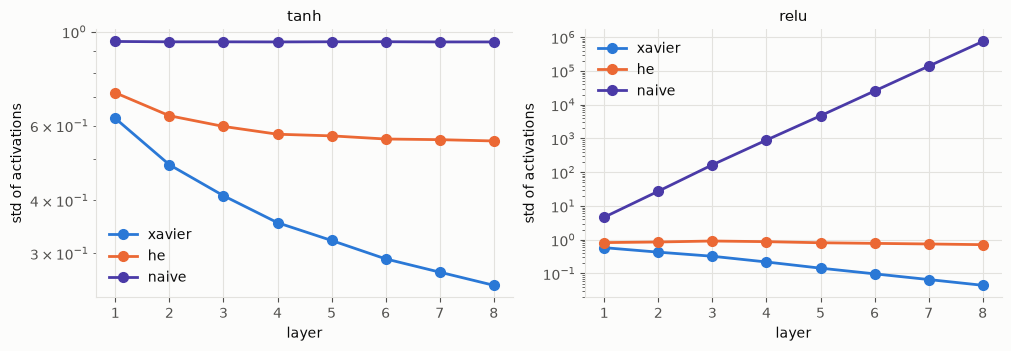

activation   init  layer           std  saturated_frac
      tanh xavier      8      0.252053        0.000000
      tanh     he      8      0.552139        0.000610
      tanh  naive      8      0.945586        0.724091
      relu xavier      8      0.044677        0.587830
      relu     he      8      0.714836        0.587830
      relu  naive      8 749559.639751        0.587830


In [5]:
from physprior.optim.report import init_depth_scan
scan = init_depth_scan()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, act in zip(axes, ["tanh", "relu"]):
    for scheme, col in [("xavier", "#2a78d6"), ("he", "#eb6834"), ("naive", "#4a3aa7")]:
        d = scan[(scan.activation == act) & (scan.init == scheme)]
        ax.semilogy(d.layer, d["std"], "o-", color=col, label=scheme)
    ax.set_title(act); ax.set_xlabel("layer"); ax.set_ylabel("std of activations"); ax.legend()
plt.show()
print(scan[scan.layer == scan.layer.max()].to_string(index=False))

With unit-variance weights the tanh network's units sit in the flat tails
(saturated: almost no gradient passes), and the ReLU network's activations
grow by orders of magnitude. The matched schemes keep the scale within a
factor of a few.

## 4. Why PINNs use tanh

A PINN's loss contains derivatives of the network with respect to its input.
A ReLU network is piecewise linear, so its second derivative is zero except at
the kinks. It cannot satisfy `u'' = -omega^2 u` anywhere.

tanh: fraction of points with |u''| < 1e-6: 0.00
relu: fraction of points with |u''| < 1e-6: 1.00


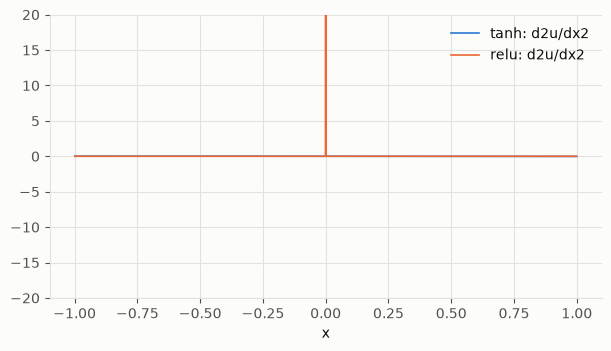

In [6]:
xs = np.linspace(-1, 1, 2001).reshape(-1, 1); h = xs[1, 0] - xs[0, 0]
fig, ax = plt.subplots(figsize=(6, 3.4))
for act, col in [("tanh", "#2a78d6"), ("relu", "#eb6834")]:
    n = S.init_mlp([1, 32, 32, 1], act, seed=1)
    u = S.forward(n, xs)[0].ravel()
    upp = (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2
    ax.plot(xs[1:-1, 0], upp, color=col, lw=1.2, label=f"{act}: d2u/dx2")
    print(f"{act}: fraction of points with |u''| < 1e-6: {np.mean(np.abs(upp) < 1e-6):.2f}")
ax.set_ylim(-20, 20); ax.legend(); ax.set_xlabel("x")
plt.show()

## 5. Optimizers, by hand

Each optimizer maps (parameters, gradient) to new parameters:

- **SGD** `theta -= lr g`. On a quadratic with Hessian eigenvalue lambda the
  error along that direction is multiplied by `(1 - lr lambda)` per step, so
  SGD is stable only for `lr < 2 / lambda_max`, and then crawls along the
  directions with small lambda.
- **Momentum** (heavy ball) accumulates a velocity: consistent gradients add
  up, oscillating ones cancel.
- **Nesterov** evaluates the gradient at the look-ahead point.
- **RMSprop** divides each coordinate by a running RMS of its gradient: a
  diagonal preconditioner.
- **Adam** is momentum plus RMSprop's scaling, with bias correction for the
  zero-initialised running averages.

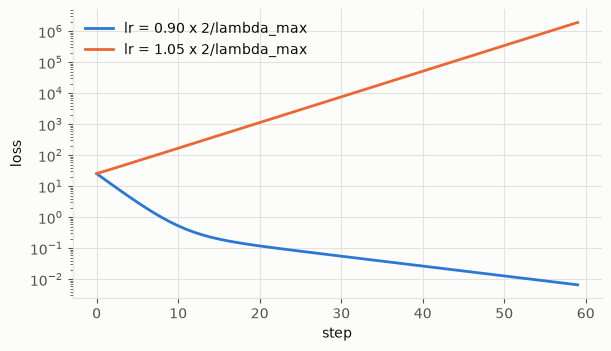

In [7]:
A = np.diag([1.0, 50.0]); lam_max = 50.0
fig, ax = plt.subplots(figsize=(6, 3.4))
for lr, col in [(0.9 * 2 / lam_max, "#2a78d6"), (1.05 * 2 / lam_max, "#eb6834")]:
    th = np.array([1.0, 1.0]); opt = S.SGD(lr); f = []
    for _ in range(60):
        f.append(0.5 * th @ A @ th); th = opt.step(th, A @ th)
    ax.semilogy(f, color=col, label=f"lr = {lr * lam_max / 2:.2f} x 2/lambda_max")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(); plt.show()

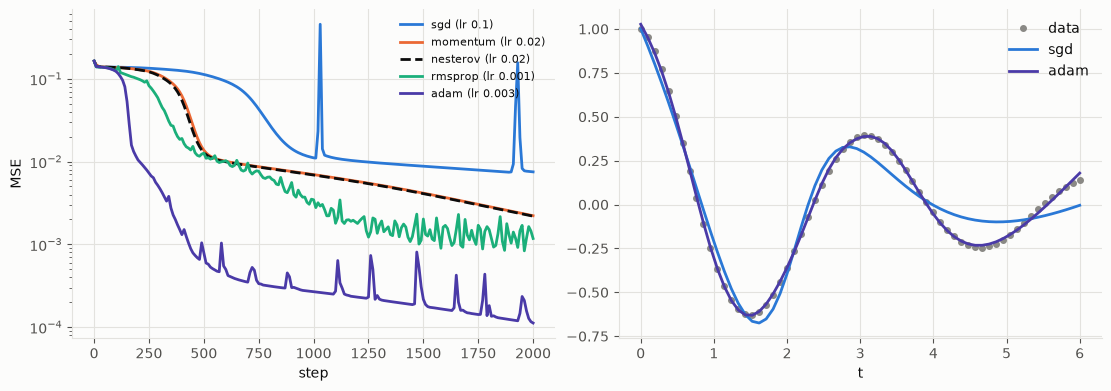

sgd       final MSE 7.51e-03
momentum  final MSE 2.22e-03
nesterov  final MSE 2.19e-03
rmsprop   final MSE 1.18e-03
adam      final MSE 1.12e-04


In [8]:
res = S.compare_optimizers(steps=2000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
cols = {"sgd": "#2a78d6", "momentum": "#eb6834", "rmsprop": "#1baf7a", "adam": "#4a3aa7", "nesterov": P.INK}
for k, v in res.items():
    h = v["history"]
    axes[0].semilogy(h["step"], h["loss"], color=cols[k], ls="--" if k == "nesterov" else "-",
                     label=f"{k} (lr {v['lr']:g})")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE"); axes[0].legend(fontsize=8)
axes[1].plot(t, y, "o", color=P.INK_MUTED, ms=4, label="data")
for k in ("sgd", "adam"):
    axes[1].plot(t, S.forward(res[k]["net"], x)[0].ravel(), color=cols[k], label=k)
axes[1].set_xlabel("t"); axes[1].legend(); plt.show()
for k, v in res.items(): print(f"{k:9s} final MSE {v['history']['loss'][-1]:.2e}")

The SGD curve shows spikes: its rate sits near the stability limit of the
sharpest direction, and when training sharpens the loss past `2 / lr` it
overshoots and recovers (the edge of stability, Cohen et al. 2021). Adam
spikes too, for the same reason in its own rescaled geometry, but its
per-coordinate scaling lets it take large steps along flat directions, which
is where SGD loses most of its time.

### Adam's bias correction

Both running averages start at zero. At step 1, `m = 0.1 g` and
`v = 0.001 g^2`, so the uncorrected step is `0.1 / sqrt(0.001) = 3.2` times
the learning rate. Dividing by `(1 - beta^t)` removes that.

In [9]:
g0 = np.array([1e-3, 1.0, -50.0])
print("with correction   ", S.Adam(lr=0.01).step(np.zeros(3), g0))
print("without correction", S.Adam(lr=0.01, bias_correction=False).step(np.zeros(3), g0))

with correction    [-0.0099999 -0.01       0.01     ]
without correction [-0.03161278 -0.03162277  0.03162278]


## Where this goes next

T9 takes these optimizers to the project's problems and asks whether a
physics model, a PINN and a black box want the same optimizer. They do not,
and the Hessian at the solution explains why.